<a href="https://colab.research.google.com/github/Aaguilar123/Macro-Liquidity-Asset-Leaderboard-Forecast/blob/Aaguilar123-patch-1/shared_eda/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Exploration, Preparation, and Feature Engineering for Liquidity Analysis

##Data Preparation and Cleaning for Merging


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

df_volume = pd.read_csv('market_volume.csv', index_col='Date', parse_dates=True)
df_macro = pd.read_csv('macro_indicators.csv', index_col='Date', parse_dates=True)

print("DATA QUALITY SUMMARY")
print(f"Time Span: {df_volume.index.min().date()} to {df_volume.index.max().date()}")
print(f"Frequency: Daily (Business Days)")
print(f"Missing Values (Volume):\n{df_volume.isnull().sum()}")
print(f"\nMissing Values (Macro):\n{df_macro.isnull().sum()}")

df_volume.head()

DATA QUALITY SUMMARY
Time Span: 2015-01-01 to 2026-04-14
Frequency: Daily (Business Days)
Missing Values (Volume):
BTC-USD    0
GLD        1
QQQ        1
UUP        1
XLP        1
dtype: int64

Missing Values (Macro):
Fed_Rate             0
CPI_Inflation        1
Unemployment_Rate    1
dtype: int64


,BTC-USD,GLD,QQQ,UUP,XLP
Date,,,,,
2015-01-01,8036550,NaN,NaN,NaN,NaN
2015-01-02,7860650,8.110632e+08,2.964399e+09,3.816104e+07,2.730110e+08
2015-01-03,33054400,8.110632e+08,2.964399e+09,3.816104e+07,2.730110e+08
2015-01-04,55629100,8.110632e+08,2.964399e+09,3.816104e+07,2.730110e+08
2015-01-05,43962800,9.469429e+08,3.406577e+09,5.784806e+07,2.946172e+08


## Preprocessing & Outlier Mitigation

In [7]:
df_macro['CPI_Inflation'] = df_macro['CPI_Inflation'].pct_change(1, fill_method=None) * 100

vol_cols = ['QQQ', 'XLP', 'GLD', 'BTC-USD', 'UUP']
df_volume_smoothed = df_volume[vol_cols].rolling(window=21).mean()

def winsorize(series, lower=0.01, upper=0.99):
    return series.clip(series.quantile(lower), series.quantile(upper))

for col in vol_cols:
    df_volume_smoothed[col] = winsorize(df_volume_smoothed[col])

df_master = df_volume_smoothed.join(df_macro, how='left').ffill().dropna()

print(f"Total observations: {len(df_master)}")
df_master.describe().round(2)



Total observations: 4091


,QQQ,XLP,GLD,BTC-USD,UUP,Fed_Rate,CPI_Inflation,Unemployment_Rate
count,4.091000e+03,4.091000e+03,4.091000e+03,4.091000e+03,4.091000e+03,4091.00,4091.00,4091.00
mean,1.269331e+10,7.180554e+08,1.654989e+09,2.277035e+10,3.557434e+07,2.06,0.26,4.63
std,9.435673e+09,3.233983e+08,1.380337e+09,2.031798e+10,2.381480e+07,1.91,0.27,1.63
min,1.993346e+09,2.134351e+08,5.050109e+08,1.981319e+07,7.991175e+06,0.05,-0.79,3.40
25%,4.600371e+09,5.036473e+08,9.118684e+08,3.800839e+09,1.966847e+07,0.20,0.12,3.80
50%,1.109029e+10,6.552326e+08,1.260316e+09,2.158186e+10,2.786666e+07,1.55,0.24,4.20
75%,1.841501e+10,8.643748e+08,1.748964e+09,3.528809e+10,4.239548e+07,4.10,0.37,4.90
max,4.243986e+10,1.929708e+09,9.617005e+09,7.488257e+10,1.217563e+08,5.33,1.26,14.80


- CPI transformation:
  - Converted CPI index into inflation rate using percentage change
  - Result expressed in % (captures month-to-month inflation dynamics)

- Volume smoothing:
  - Applied 21-day rolling mean (~1 trading month)
  - Reduces noise and highlights underlying trends

- Outlier handling:
  - Winsorized each volume series (1% lower, 99% upper)
  - Caps extreme spikes without removing data

- Data integration:
  - Joined smoothed volume data with macro data
  - Forward-filled missing macro values
  - Dropped remaining NaNs to ensure clean dataset

## Exploration of Trends & Seasonality

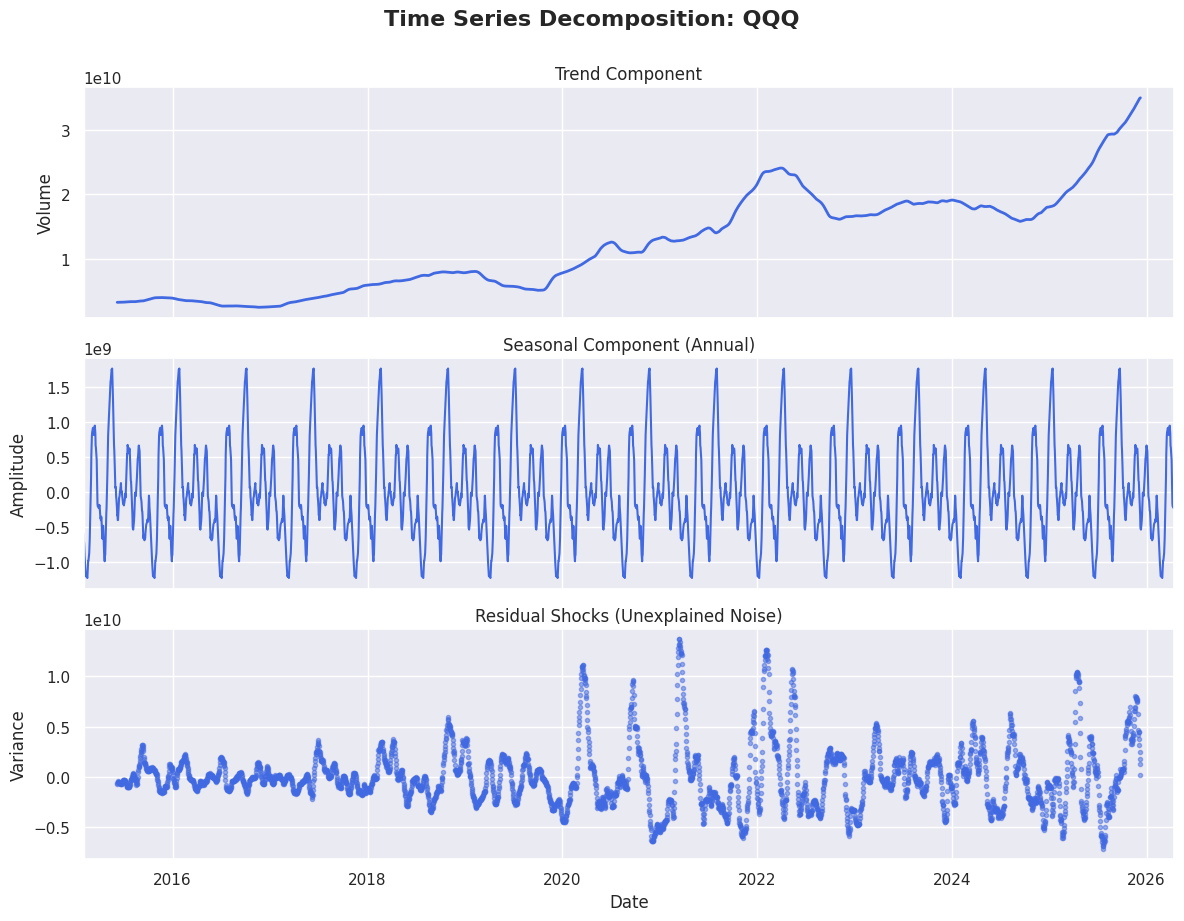

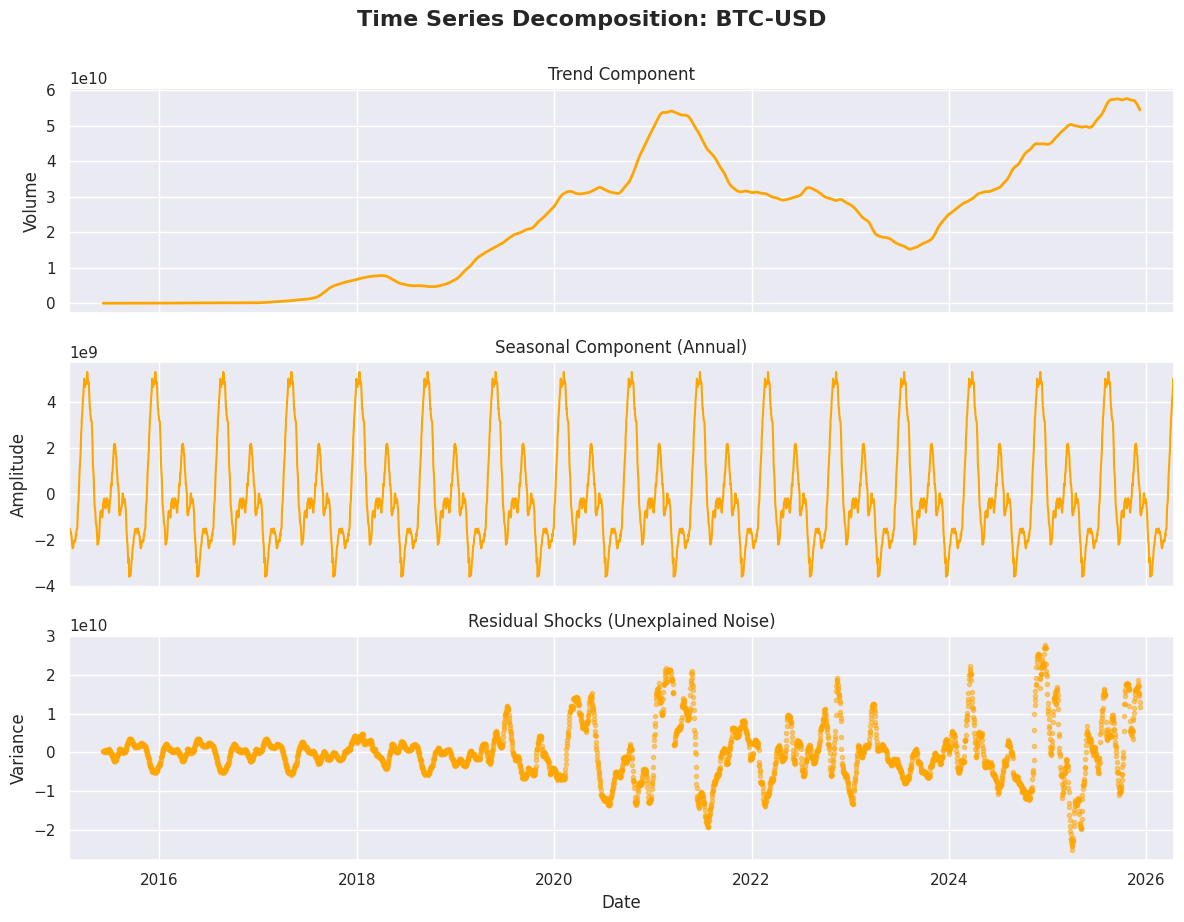

In [8]:
assets_to_compare = ['QQQ', 'BTC-USD']

for asset in assets_to_compare:
    line_color = 'orange' if asset == 'BTC-USD' else 'royalblue'

    res = seasonal_decompose(df_master[asset], model='additive', period=252)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'Time Series Decomposition: {asset}', fontsize=16, fontweight='bold', y=0.95)

    res.trend.plot(ax=ax1, title=f'Trend Component', color=line_color, linewidth=2)
    ax1.set_ylabel('Volume')

    res.seasonal.plot(ax=ax2, title=f'Seasonal Component (Annual)', color=line_color, linewidth=1.5)
    ax2.set_ylabel('Amplitude')

    res.resid.plot(ax=ax3, title=f'Residual Shocks (Unexplained Noise)', color=line_color, style='.', alpha=0.5)
    ax3.set_ylabel('Variance')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Compare volume dynamics of QQQ (structural) vs BTC (speculative)

- Trend:
  - QQQ shows smooth, steady growth with mild drawdowns (e.g., 2020, 2022)
  - BTC shows sharp expansions and contractions, indicating high volatility

- Seasonality:
  - Both exhibit annual seasonality (period=252 trading days)
  - QQQ seasonality is stable and consistent
  - BTC seasonality is stronger and more erratic

- Residuals (shocks):
  - QQQ has relatively small, controlled residual noise
  - BTC shows large, clustered shocks (especially 2020–2022)

Focus:
- QQQ behaves like a stable, institution-driven asset
- BTC behaves like a speculative, sentiment-driven asset with higher volatility

## Defining Forecasting Goals & Multi-Horizon Targets

In [9]:
target_columns_3m = []
horizon_days = 63

for col in vol_cols:
    target_name = f"{col}_Target_RVOL_3M"

    future_vol = df_master[col].shift(-horizon_days)
    current_vol = df_master[col]

    raw_target = np.log(future_vol / current_vol) * 100
    df_master[target_name] = raw_target.rolling(window=5).mean()
    target_columns_3m.append(target_name)

df_master.dropna(inplace=True)

# CSV
features = vol_cols + ['Fed_Rate', 'CPI_Inflation', 'Unemployment_Rate']
export_cols = features + target_columns_3m

df_master[export_cols].to_csv('final_engineered_data.csv')
print("CSV Exported. Contains ONLY Machine Learning Features and 3M Targets.")
final = pd.read_csv('final_engineered_data.csv', index_col='Date', parse_dates=True)
print(final.head())

CSV Exported. Contains ONLY Machine Learning Features and 3M Targets.
                     QQQ           XLP           GLD       BTC-USD  \
Date                                                                 
2015-02-05  3.461199e+09  3.509618e+08  1.307192e+09  3.373754e+07   
2015-02-06  3.459389e+09  3.393536e+08  1.297627e+09  3.307155e+07   
2015-02-07  3.457579e+09  3.277453e+08  1.288061e+09  3.298272e+07   
2015-02-08  3.455769e+09  3.161370e+08  1.278495e+09  3.236653e+07   
2015-02-09  3.401404e+09  3.033317e+08  1.224037e+09  3.280144e+07   

                     UUP  Fed_Rate  CPI_Inflation  Unemployment_Rate  \
Date                                                                   
2015-02-05  4.873629e+07      0.11       0.253464                5.5   
2015-02-06  4.855092e+07      0.11       0.253464                5.5   
2015-02-07  4.836555e+07      0.11       0.253464                5.5   
2015-02-08  4.818018e+07      0.11       0.253464                5.5   
2015-02

A 3-month (63 trading days) horizon was selected based on EDA below. The target is defined as the log percentage change in volume (RVOL -> Relative Volume), which ensures symmetry and reduces the impact of extreme values common in financial data. A 5-day rolling mean is applied to the target to smooth short-term noise and improve model stability while preserving the underlying macro signal.

## Explanatory Data Analysis

### Macro Regime Sensitivity (Heatmaps)


>>> Dynamically calculating EDA variables (Regimes, 1M, 6M)...


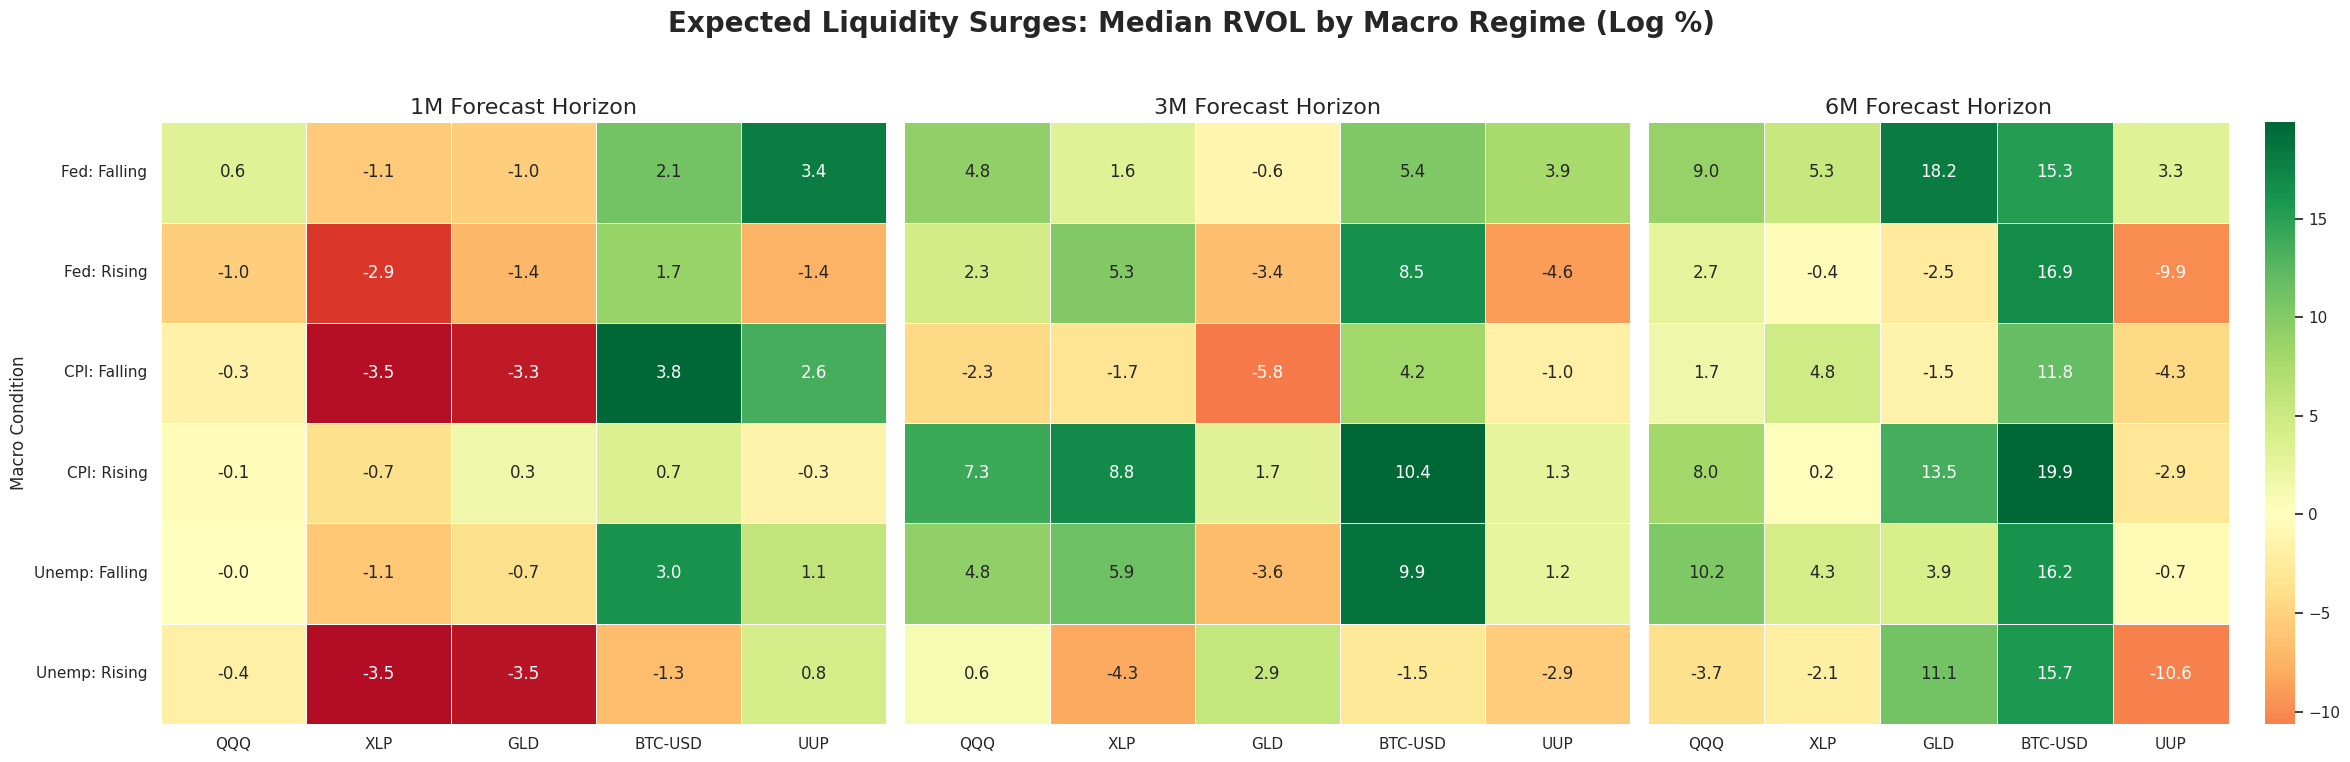

In [10]:
print("\n Dynamically calculating EDA variables (Regimes, 1M, 6M)...")

df_master['Fed_State'] = np.where(df_master['Fed_Rate'].diff(60) > 0, 'Fed: Rising', 'Fed: Falling')
df_master['CPI_State'] = np.where(df_master['CPI_Inflation'].diff(60) > 0, 'CPI: Rising', 'CPI: Falling')
df_master['Unemp_State'] = np.where(df_master['Unemployment_Rate'].diff(60) > 0, 'Unemp: Rising', 'Unemp: Falling')

eda_targets = target_columns_3m.copy()
eda_horizons = {'1M': 21, '6M': 126}

for label, h_days in eda_horizons.items():
    for col in vol_cols:
        t_name = f"{col}_Target_RVOL_{label}"
        raw_t = np.log(df_master[col].shift(-h_days) / df_master[col]) * 100
        df_master[t_name] = raw_t.rolling(window=5).mean()
        eda_targets.append(t_name)

# Heatmaps
def plot_macro_heatmaps(df, targets):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
    fig.suptitle('Expected Liquidity Surges: Median RVOL by Macro Regime (Log %)', fontsize=20, fontweight='bold')

    for i, label in enumerate(['1M', '3M', '6M']):
        hz_cols = [c for c in targets if label in c]
        agg_data = pd.concat([
            df.groupby('Fed_State')[hz_cols].median(),
            df.groupby('CPI_State')[hz_cols].median(),
            df.groupby('Unemp_State')[hz_cols].median()
        ])
        agg_data.columns = [c.replace(f'_Target_RVOL_{label}', '') for c in agg_data.columns]
        sns.heatmap(agg_data, annot=True, cmap='RdYlGn', center=0, fmt=".1f", linewidths=.5, ax=axes[i], cbar=(i==2))
        axes[i].set_title(f'{label} Forecast Horizon', fontsize=16)
        if i == 0: axes[i].set_ylabel('Macro Condition', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_macro_heatmaps(df_master, eda_targets)

### Macro Regime Analysis — Expected Liquidity Surges

The heatmaps show median forward RVOL (log %) across macro regimes (Fed, CPI, Unemployment) for 1M, 3M, and 6M horizons.

Overall, the results indicate that **liquidity responses are regime-dependent and non-linear**, with stronger and more interpretable patterns emerging at longer horizons.

- **1M Horizon:**  
  Signals are **noisy and inconsistent**, with mixed signs across assets and regimes.  
  Short-term liquidity changes appear dominated by **idiosyncratic and microstructure effects**, limiting macro interpretability.

- **3M Horizon:**  
  Clearer structure emerges, particularly:
  - **BTC and QQQ show strong positive RVOL under rising CPI and falling unemployment**, indicating increased participation during macro stress or growth transitions.  
  - **XLP and GLD exhibit mixed or defensive behavior**, aligning with their roles as lower-beta or hedge assets.  
  - **UUP reacts negatively in some inflation/rate regimes**, suggesting FX positioning depends on broader policy expectations rather than simple directional moves.

- **6M Horizon:**  
  Signals become **stronger but more diffuse**, with large positive values across multiple regimes.  
  However, this likely reflects **lagging effects and overlapping macro cycles**, reducing timing precision.

---
A 3-month (63 trading days) horizon was selected based on EDA, as it provided the best balance between noise (1M) and lag (6M), capturing macro-driven capital rotation more clearly

### Variance & Outlier Distribution (Boxplots)


 MACRO-CONDITIONED DISTRIBUTION ANALYSIS (Log-RVOL)


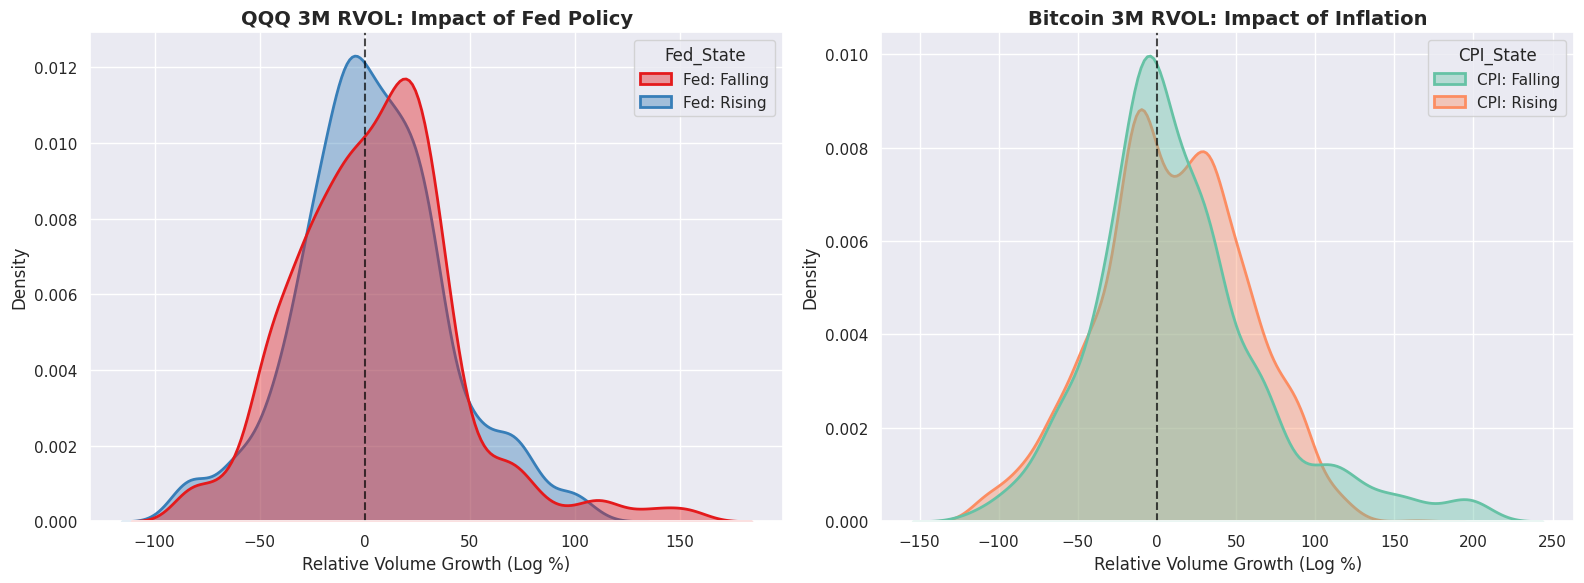


 OUTLIER DIAGNOSTIC: Cross-Asset Variance


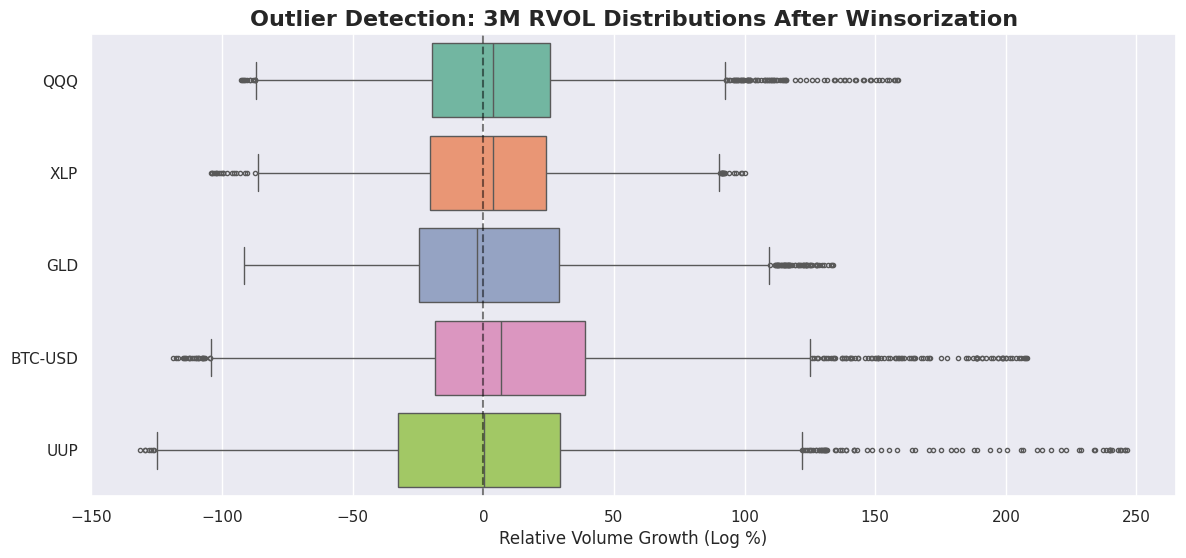

In [13]:
print("\n MACRO-CONDITIONED DISTRIBUTION ANALYSIS (Log-RVOL)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_master, x='QQQ_Target_RVOL_3M', hue='Fed_State',
            fill=True, common_norm=False, alpha=0.4, ax=axes[0], palette='Set1', linewidth=2)
axes[0].set_title('QQQ 3M RVOL: Impact of Fed Policy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Relative Volume Growth (Log %)')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.7)


sns.kdeplot(data=df_master, x='BTC-USD_Target_RVOL_3M', hue='CPI_State',
            fill=True, common_norm=False, alpha=0.4, ax=axes[1], palette='Set2', linewidth=2)
axes[1].set_title('Bitcoin 3M RVOL: Impact of Inflation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Volume Growth (Log %)')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n OUTLIER DIAGNOSTIC: Cross-Asset Variance")
target_3m_cols = [c for c in df_master.columns if '_Target_RVOL_3M' in c]
plt.figure(figsize=(14, 6))

sns.boxplot(data=df_master[target_3m_cols], orient="h", palette="Set2", fliersize=3)
plt.yticks(ticks=range(len(target_3m_cols)), labels=[c.replace('_Target_RVOL_3M', '') for c in target_3m_cols])

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Outlier Detection: 3M RVOL Distributions After Winsorization', fontsize=16, fontweight='bold')
plt.xlabel('Relative Volume Growth (Log %)', fontsize=12)
plt.show()

### Distribution & Outlier Analysis — 3M RVOL

RVOL is **skewed, fat-tailed, and regime-dependent**.

- **QQQ vs Fed:**
  Fed cuts -> distribution shifts right (higher liquidity)  
  Fed hikes -> shifts left (weaker liquidity)  
  -> clear directional sensitivity to policy

- **BTC vs CPI:**  
  Rising inflation -> fatter right tail -> higher probability of liquidity surges  

Across assets:
- BTC and UUP drive extreme upside tails
- GLD and XLP remain tighter, QQQ in between  

### Key Insight

Liquidity is **non-linear and concentrated in tails**:  
macro regimes shift *where* extremes occur, not averages  

-> Requires **asset-specific, non-linear individual modeling**

### Feature Sensitivity & Momentum

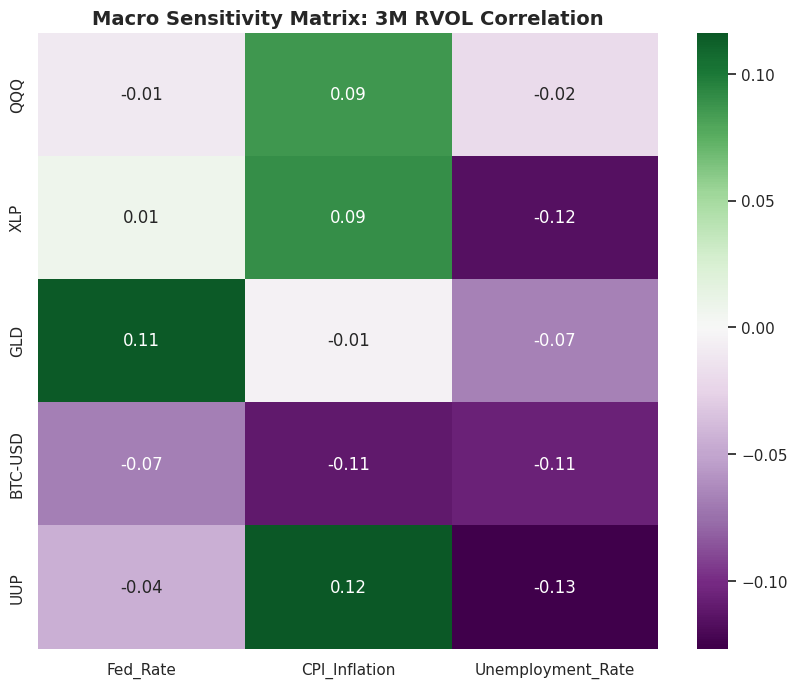

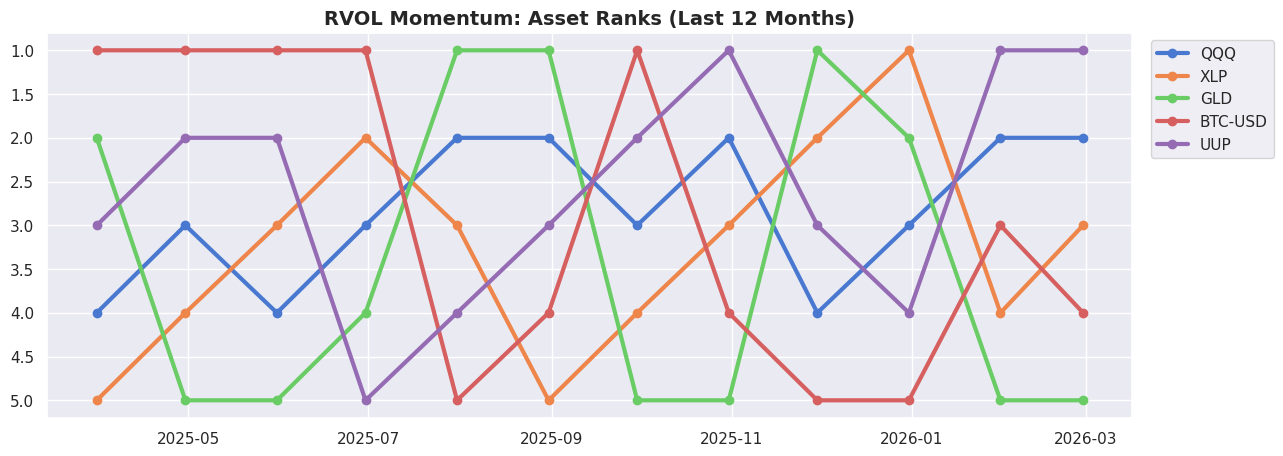

In [18]:
# Sensitivity Matrix (Correlation)
macro_vars = ['Fed_Rate', 'CPI_Inflation', 'Unemployment_Rate']

target_columns = df_master.columns

target_3m = [c for c in target_columns if '3M' in c]
corr_matrix = df_master[target_3m + macro_vars].corr().loc[target_3m, macro_vars]
corr_matrix.index = [c.replace('_Target_RVOL_3M', '') for c in corr_matrix.index]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='PRGn', center=0, fmt=".2f")
plt.title('Macro Sensitivity Matrix: 3M RVOL Correlation', fontsize=14, fontweight='bold')
plt.show()

# 12-Month Momentum Leaderboard
hz_cols = [c for c in target_columns if '3M' in c]
monthly_ranks = df_master[hz_cols].resample('ME').last().rank(axis=1, ascending=False)
monthly_ranks.columns = [c.replace('_Target_RVOL_3M', '') for c in monthly_ranks.columns]

plt.figure(figsize=(14, 5))
for col in monthly_ranks.columns:
    plt.plot(monthly_ranks.index[-12:], monthly_ranks[col].tail(12), marker='o', linewidth=3, label=col)
plt.gca().invert_yaxis()
plt.title('RVOL Momentum: Asset Ranks (Last 12 Months)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

The macro sensitivity matrix shows statistically weak but economically consistent relationships, reinforcing the need for non-linear models to capture complex interactions in financial liquidity dynamics.


### RVOL Momentum (12M) — Macro Narrative

*Since rankings are based on 3-month forward RVOL, these patterns reflect realized future liquidity shifts, not immediate market reactions.*

---

**Phase 1: Apr–Jul 2025 — Disinflation / Risk-On Liquidity**  
- CPI declining (~2.7% -> ~2.3%)  
- Fed near peak / transitioning from prior tightening  
- Unemployment gradually rising (~4.0% -> ~4.3%)

RVOL:
- BTC consistently rank 1  
- GLD low (4–5), QQQ/XLP mid  

Interpretation:  
Liquidity concentrates in risk assets (BTC), consistent with soft-landing expectations and easing financial conditions.

---

**Phase 2: Aug–Nov 2025 — Labor Weakness / Policy Easing Transition**  
- CPI stabilizes (~2.6–2.8%)  
- Unemployment peaks (~4.4–4.5%)  
- **Fed begins rate cuts (easing cycle starts)**

RVOL:
- GLD rank 1 (Aug–Sep) -> short-term hedging demand  
- BTC loses leadership  
- XLP steadily climbs -> sustained defensive allocation  
- UUP trends upward -> increasing USD demand  

Interpretation:  
Despite policy easing, liquidity rotates away from speculative assets toward defensive (XLP) and macro-sensitive assets (UUP), reflecting growth concerns dominating rate cuts.

---

**Phase 3: Dec 2025 – Mar 2026 — Inflation Repricing / Macro Liquidity**  
- CPI re-accelerates (~2.4% -> ~3.3%)  
- **Fed holds ~3.75% after prior cuts (easing paused)**  
- Unemployment stabilizes (~4.3–4.4%)

RVOL:
- UUP becomes dominant (rank 1)  
- XLP peaks earlier (Jan)  
- GLD declines to low ranks  
- BTC remains unstable  

Interpretation:  
Liquidity shifts toward USD exposure, reflecting renewed inflation pressure and repricing of the rate path.  
Macro positioning is expressed primarily through FX (UUP), not gold.

---

### Final Insight

RVOL rankings reveal a sequenced rotation in future liquidity leadership:  
BTC (risk) -> GLD (short-term hedge) -> XLP (defensive build-up) -> UUP (macro positioning)

QQQ remains relatively stable across phases, acting as a structural liquidity anchor rather than a primary vehicle for macro-driven rotation.

## Statistical Diagnostic & Evaluation Setup

In [19]:
print("STATISTICAL DIAGNOSTIC: SIGNAL-TO-NOISE RATIO (SNR)")

snr_stats = df_master.groupby('Fed_State')[target_3m].agg(['median', 'std']).round(2)

snr_stats.columns = pd.MultiIndex.from_tuples([(c[0].replace('_Target_RVOL_3M', ''), c[1]) for c in snr_stats.columns])
print(snr_stats)

print("\n EVALUATION CRITERIA DEFINITION")
print("Primary Metric: Mean Absolute Error (MAE) - Robust to outlier noise.")
print("Secondary Metric: RMSE - Penalizes large forecasting misses.")
print("Validation Strategy: Chronological Time-Series Split (No random shuffling).")

STATISTICAL DIAGNOSTIC: SIGNAL-TO-NOISE RATIO (SNR)
                QQQ           XLP           GLD        BTC-USD           UUP  \
             median    std median    std median    std  median    std median   
Fed_State                                                                      
Fed: Falling   4.77  38.51   1.65  33.43  -0.64  44.78    5.38  48.41   3.94   
Fed: Rising    2.34  35.48   5.32  33.52  -3.42  37.43    8.51  51.77  -4.61   

                     
                std  
Fed_State            
Fed: Falling  52.09  
Fed: Rising   47.60  

 EVALUATION CRITERIA DEFINITION
Primary Metric: Mean Absolute Error (MAE) - Robust to outlier noise.
Secondary Metric: RMSE - Penalizes large forecasting misses.
Validation Strategy: Chronological Time-Series Split (No random shuffling).


RVOL exhibits low signal-to-noise ratios across assets, with high volatility dominating median effects, reinforcing the need for robust, non-linear, and asset-specific modeling approaches.